In [1]:
#%pip install qiskit-algorithms

from qiskit import QuantumCircuit
from qiskit.circuit.library import PhaseOracle
from qiskit.visualization import plot_histogram
from qiskit_algorithms import Grover, AmplificationProblem
# DÜZELTME: Eski 'Sampler' yerine 'StatevectorSampler' kullanıyoruz
from qiskit.primitives import StatevectorSampler as Sampler 
import matplotlib.pyplot as plt

In [2]:
expression = '((James & Lars) | (Kirk & Rob)) & ~(Lars & Rob)'
oracle = PhaseOracle(expression)

C:\Users\umran\AppData\Local\Temp\ipykernel_34404\3551230967.py:2: DeprecationWarning: The class ``qiskit.circuit.library.phase_oracle.PhaseOracle`` is deprecated as of Qiskit 2.2. It will be removed in Qiskit 3.0. Use the class qiskit.circuit.library.PhaseOracleGate instead.
  oracle = PhaseOracle(expression)


In [3]:
problem = AmplificationProblem(oracle=oracle, is_good_state=oracle.evaluate_bitstring)

In [4]:
# StatevectorSampler, yerel simülasyon için en hızlısıdır
sampler = Sampler()
grover = Grover(sampler=sampler)

In [5]:
result = grover.amplify(problem)

In [6]:
counts = result.circuit_results[0]
print("Tüm Olasılıklar (Ham Veri):", counts)

Tüm Olasılıklar (Ham Veri): {'0111': 0.2451171875, '0011': 0.2666015625, '1100': 0.240234375, '1101': 0.248046875}


In [7]:
# result.assignment bize kazanan dizilimi (örn: '0101') verir.
print(f"En İyi Sonuç (Kazanan Durum): {result.assignment}")

En İyi Sonuç (Kazanan Durum): 0011


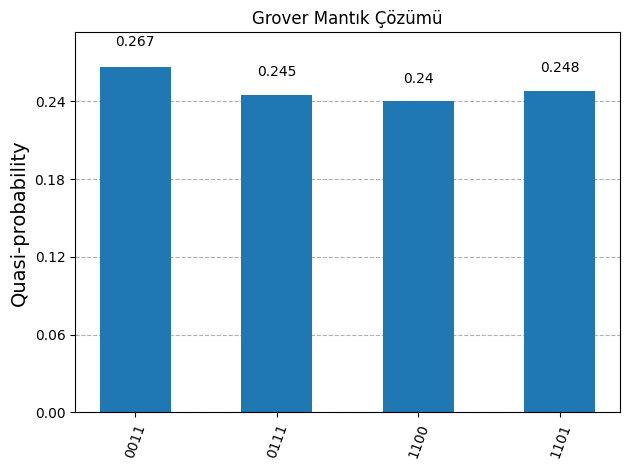

In [8]:
from IPython.display import display
display(plot_histogram(counts, title="Grover Mantık Çözümü"))